# **TIME SERIES ANALYSIS -** STOCK PRICE DATASET

In [1]:
import pandas as pd

sp = pd.read_csv("2) Stock Prices Data Set.csv")

In [2]:
sp.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [3]:
sp.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [4]:
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [6]:
sp["symbol"].nunique()

505

In [7]:
sp["symbol"].value_counts()

symbol
AAL     1007
PRGO    1007
NVDA    1007
NUE     1007
NTRS    1007
        ... 
DXC      189
BHGE     126
BHF      117
DWDP      83
APTV      18
Name: count, Length: 505, dtype: int64

In [8]:
sp.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [9]:
# Identify most occuring symbols with complete entries

symbol_count = sp["symbol"].value_counts()
max_symbol_count = symbol_count.max()
top_symbol = symbol_count[symbol_count == max_symbol_count].index[:5]

top_symbol

Index(['AAL', 'PRGO', 'NVDA', 'NUE', 'NTRS'], dtype='object', name='symbol')

In [10]:
top5symbols = sp[sp["symbol"].isin(top_symbol)].copy()
top5symbols

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.07,25.820,25.060,25.36,8998943
328,NTRS,2014-01-02,61.76,61.950,60.665,60.89,1011050
329,NUE,2014-01-02,53.29,53.380,52.510,52.73,1611326
330,NVDA,2014-01-02,15.92,15.980,15.720,15.86,6502296
363,PRGO,2014-01-02,152.45,154.520,152.110,153.10,1209456
...,...,...,...,...,...,...,...
496967,AAL,2017-12-29,52.42,52.820,52.010,52.03,2697096
497311,NTRS,2017-12-29,100.56,101.455,99.860,99.89,637509
497312,NUE,2017-12-29,64.75,64.750,63.570,63.58,1519439
497313,NVDA,2017-12-29,198.46,198.460,193.500,193.50,6999116


In [11]:
top5symbols["date"] = pd.to_datetime(top5symbols["date"])

In [12]:
import matplotlib.pyplot as plt
import seaborn as sb

**EXPLORATORY TIME ANALYSIS- CHANGES IN CLOSING PRICE OF SELECT STOCK OVER TIME**

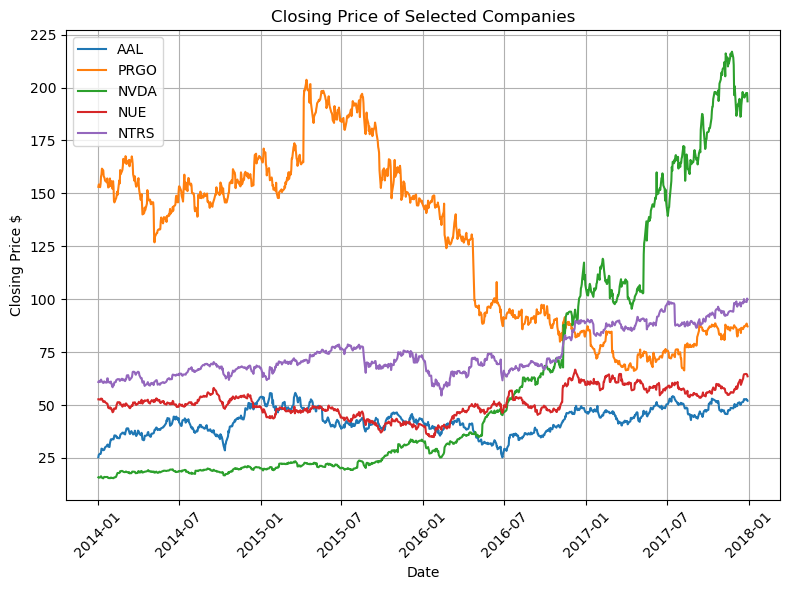

In [13]:
plt.figure(figsize=(8,6))

for symbol in top_symbol:
    company = top5symbols[top5symbols["symbol"]==symbol]
    plt.plot(company["date"], company["close"], label=symbol)

plt.title("Closing Price of Selected Companies")
plt.xlabel("Date")
plt.ylabel("Closing Price $")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**PERCENTAGE GROWTH ANALYSIS**

In [14]:
symbols = top5symbols["symbol"].unique()

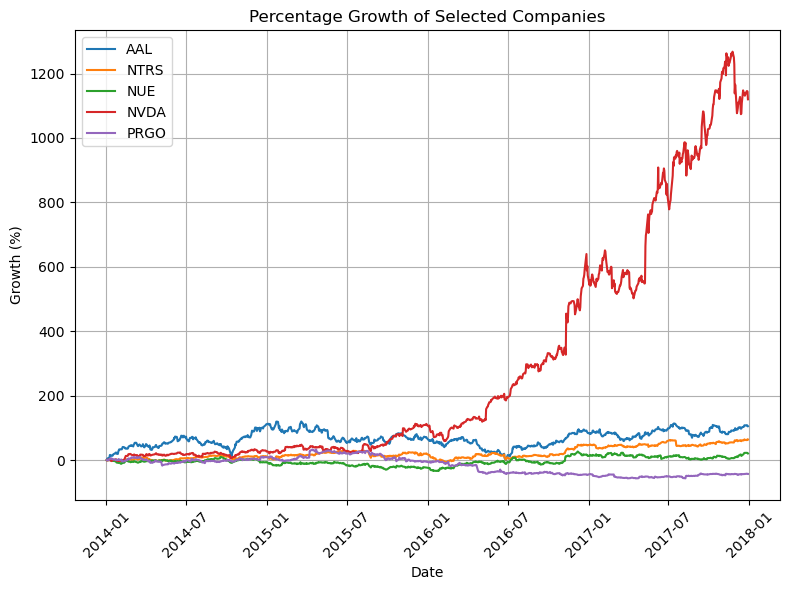

In [15]:
plt.figure(figsize=(8, 6))

for symbol in symbols:
    company = top5symbols[top5symbols["symbol"] == symbol].copy()

    company["pct_growth"] = (company["close"] / company["close"].iloc[0] - 1) * 100

    plt.plot(company["date"], company["pct_growth"], label=symbol)

plt.title("Percentage Growth of Selected Companies")
plt.xlabel("Date")
plt.ylabel("Growth (%)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Key Insight – Percentage Growth**

Percentage Growth compares today's price with the first day's price. Among the selected companies, NVDA recorded the strongest cumulative growth over the given period, significantly outperforming its peers. In contrast, PRGO experienced the weakest growth even incurring losses, making these two companies suitable candidates for deeper time-series analysis. 

**DAILY VOLATILITY**

In [16]:
symbols = top5symbols["symbol"].unique()

volatility_summary = []

for symbol in symbols:
    company = top5symbols[top5symbols["symbol"]==symbol].copy()
    company = company.sort_values("date")
    
    daily_return = company["close"].pct_change() * 100
   
    company["daily_return"] = daily_return

    volatility = company["daily_return"].std()
    
    volatility_summary.append({"Symbol":symbol, "Volatility":volatility})
    print(volatility_summary)

[{'Symbol': 'AAL', 'Volatility': 2.238868341352129}]
[{'Symbol': 'AAL', 'Volatility': 2.238868341352129}, {'Symbol': 'NTRS', 'Volatility': 1.3806060722295004}]
[{'Symbol': 'AAL', 'Volatility': 2.238868341352129}, {'Symbol': 'NTRS', 'Volatility': 1.3806060722295004}, {'Symbol': 'NUE', 'Volatility': 1.6674995186555477}]
[{'Symbol': 'AAL', 'Volatility': 2.238868341352129}, {'Symbol': 'NTRS', 'Volatility': 1.3806060722295004}, {'Symbol': 'NUE', 'Volatility': 1.6674995186555477}, {'Symbol': 'NVDA', 'Volatility': 2.3738853039732764}]
[{'Symbol': 'AAL', 'Volatility': 2.238868341352129}, {'Symbol': 'NTRS', 'Volatility': 1.3806060722295004}, {'Symbol': 'NUE', 'Volatility': 1.6674995186555477}, {'Symbol': 'NVDA', 'Volatility': 2.3738853039732764}, {'Symbol': 'PRGO', 'Volatility': 2.142584660947524}]


In [17]:
volatility_summary =pd.DataFrame(volatility_summary)
volatility_summary

,Symbol,Volatility
0,AAL,2.238868
1,NTRS,1.380606
2,NUE,1.667500
3,NVDA,2.373885
4,PRGO,2.142585


In [18]:
volatility_summary["Volatility"] = volatility_summary["Volatility"].round(2)
volatility_summary

,Symbol,Volatility
0,AAL,2.24
1,NTRS,1.38
2,NUE,1.67
3,NVDA,2.37
4,PRGO,2.14


In [19]:
volatility_ranked = volatility_summary.sort_values("Volatility")
volatility_ranked

,Symbol,Volatility
1,NTRS,1.38
2,NUE,1.67
4,PRGO,2.14
0,AAL,2.24
3,NVDA,2.37


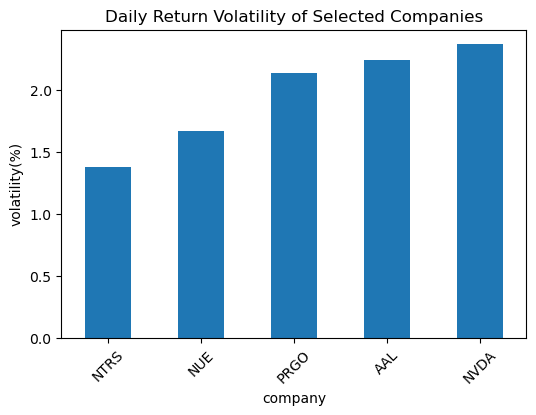

In [20]:
volatility_ranked.index = volatility_ranked["Symbol"]

volatility_ranked["Volatility"].plot(kind="bar", figsize=(6,4))
plt.title("Daily Return Volatility of Selected Companies")
plt.xlabel("company")
plt.ylabel("volatility(%)")
plt.xticks(rotation=45) 

plt.show()

**Key Insight – Volatility**

**NVDA** with the highest volatility of 2.37% shows that it has the **largest daily price fluctuations** among the selected companies during the period covered. This is interesting because, earlier I found that **NVDA also had the highest cumulative growth**. That suggests an important investment principle: **Higher returns often come with higher risk**.

**NTRS** with the lowest volatility of 1.38% suggests a **relatively stable price fluctuation**, making it the most stable amongst the five. Eventhough it had a relatively low percentage growth.

**PRGO** showed a **relatively high volatility** at 2.14% and the **weakest growth performance** with losses incurred. It goes without saying that investors experienced relatively large daily fluctuations without enjoying strong long-term growth; this is not encouraging

**These findings indicate the risk and return involved in stock trading.**

**NVDA** and **PRGO** will be subjects for further analysis due to their peculiarity as best behaving and worst behaving in cummulative growth

# **SEASONAL DECOMPOSITION**

**1. DECOMPOSITION OF NVDA**

In [21]:
nvda = top5symbols[top5symbols["symbol"]=="NVDA"].copy()
nvda

,symbol,date,open,high,low,close,volume
330,NVDA,2014-01-02,15.92,15.9800,15.7200,15.86,6502296
813,NVDA,2014-01-03,15.89,15.9201,15.6200,15.67,6483288
1296,NVDA,2014-01-06,15.83,16.0000,15.6800,15.88,10237417
1779,NVDA,2014-01-07,16.04,16.2000,15.9250,16.14,8332170
2262,NVDA,2014-01-08,16.20,16.4400,16.1400,16.36,7704980
...,...,...,...,...,...,...,...
495293,NVDA,2017-12-22,194.40,195.6500,191.2500,195.27,11656871
495798,NVDA,2017-12-26,193.03,197.7500,191.8200,197.44,8877033
496303,NVDA,2017-12-27,196.90,199.9700,196.3100,197.17,8237223
496808,NVDA,2017-12-28,198.13,199.3800,197.1514,197.40,6006248


In [22]:
nvda["date"] = pd.to_datetime(nvda["date"])

nvda = nvda.sort_values("date")

nvda = nvda.set_index("date")

nvda.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,NVDA,15.92,15.9800,15.720,15.86,6502296
2014-01-03,NVDA,15.89,15.9201,15.620,15.67,6483288
2014-01-06,NVDA,15.83,16.0000,15.680,15.88,10237417
2014-01-07,NVDA,16.04,16.2000,15.925,16.14,8332170
2014-01-08,NVDA,16.20,16.4400,16.140,16.36,7704980


In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

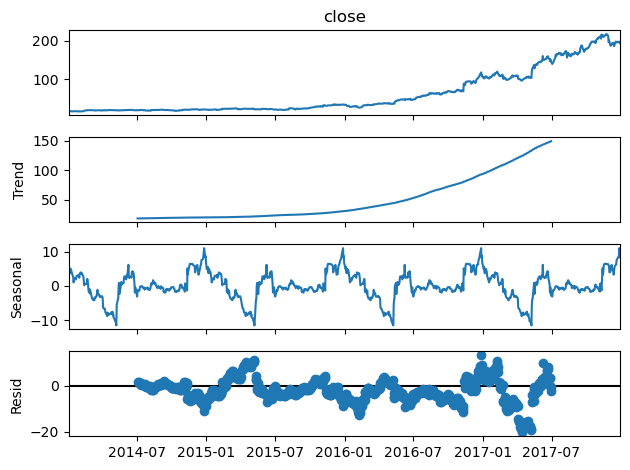

In [24]:
decomposition = seasonal_decompose(
    nvda["close"],
    model="additive",
    period=252)

decomposition.plot()

plt.show()

The **decomposition of NVDA's daily closing prices** reveals a slow increase in closing price during the start period. Over time, it experienced a **continuous upward trend**, particularly from 2016 onward, although having some fluctuations it sustained an **accelerating growth** over the study period.
The **seasonal component** exhibits recurring fluctuations based on the assumed annual trading cycle (252 trading days), but these fluctuations are relatively small compared with the overall price movement, suggesting that seasonality is not the primary driver of the stock's performance. 
The **residual component** is centered around zero with several notable spikes, indicating irregular price movements likely associated with broader market events.
**Overall**, the analysis suggests that NVDA's stock performance during the study period was driven predominantly by long-term growth rather than seasonal effects, while still being influenced by unpredictable market volatility.

**2. DECOMPOSITION OF PRGO**

In [25]:
prgo = top5symbols[top5symbols["symbol"]=="PRGO"].copy()
prgo["date"] = pd.to_datetime(prgo["date"])

prgo = prgo.sort_values("date")

prgo = prgo.set_index("date")

prgo.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,PRGO,152.45,154.52,152.11,153.10,1209456
2014-01-03,PRGO,152.99,154.38,152.61,154.23,712255
2014-01-06,PRGO,154.89,155.27,152.43,152.93,1029774
2014-01-07,PRGO,154.73,155.33,153.71,154.58,1384571
2014-01-08,PRGO,154.61,158.16,154.60,158.03,1720224


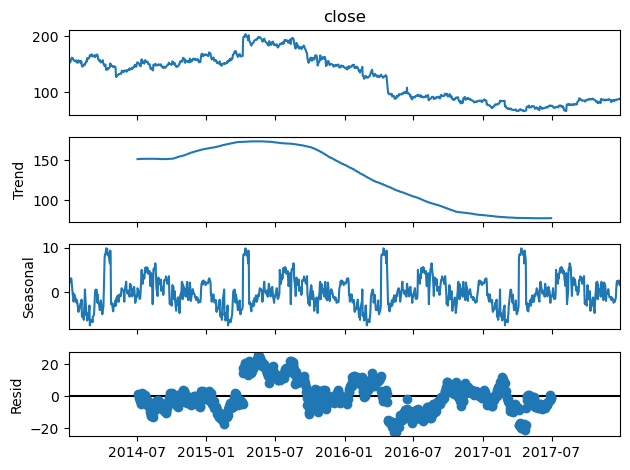

In [26]:
decomposition = seasonal_decompose(
    prgo["close"],
    model="additive",
    period=252)
decomposition.plot()

plt.show()

**PRGO** started the period with a high price of around $150 and an increase with 2015 recording the peak. From late 2015, the stock entered into a period of prolonged decline. However, towards the end of study period, the stock seemed to strive towards making a recovery.
**The Trend** decomposition reveals a stock that transitioned from moderate growth to a long-term decline. The Trend can be grouped into three phases: (1) 2014-2015 where PRGO experienced a remarkable upward trend. (2) Late 2015-2016 where there was a sharp downward movement (3) 2017 where the trend flattens
**The Seasonal** decomposition reveals are more irregular compared to NVDA. A recurring pattern was observed , howver, similar to NVDA the magnitude is relatively small compared to the overall decline in stock price. I therefore infer that seasonality is not the primary driver of PRGO's performance
**The Residual** component  highlights several irregular market movements with breaks at some points.
**Overall**, PRGO's persistent downward performance was not primarily influenced by seasonality.

# COMPARISON OF NVDA AND PRGO DECOMPOSITION

The decomposition highlights two contrasting stock behaviors. **NVDA** exhibits a strong and accelerating upward trend, indicating sustained growth and increasing investor confidence. In contrast, **PRGO** experiences an early period of growth followed by a prolonged decline, reflecting weakening market performance. While both stocks display recurring seasonal patterns under the assumed annual cycle, these effects are relatively minor compared with their long-term trends. In both cases, the residual components capture irregular price movements caused by unpredictable market events.

# **MOVING AVERAGE SMOOTHING**

**1. NVDA MOVING AVERAGE SMOOTHING**

In [27]:
nvda["MA_5"] = nvda["close"].rolling(window=5).mean()   # Weekly moving average

nvda["MA_21"] = nvda["close"].rolling(window=21).mean() # Monthly moving average

nvda.head()

,symbol,open,high,low,close,volume,MA_5,MA_21
date,,,,,,,,
2014-01-02,NVDA,15.92,15.9800,15.720,15.86,6502296,NaN,NaN
2014-01-03,NVDA,15.89,15.9201,15.620,15.67,6483288,NaN,NaN
2014-01-06,NVDA,15.83,16.0000,15.680,15.88,10237417,NaN,NaN
2014-01-07,NVDA,16.04,16.2000,15.925,16.14,8332170,NaN,NaN
2014-01-08,NVDA,16.20,16.4400,16.140,16.36,7704980,15.982,NaN


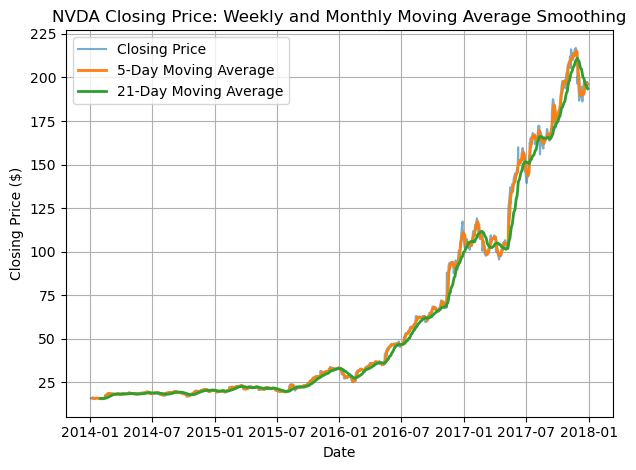

In [28]:
plt.plot(nvda.index, nvda["close"], label="Closing Price", alpha=0.6)
plt.plot(nvda.index, nvda["MA_5"], label= "5-Day Moving Average", linewidth=2)
plt.plot(nvda.index, nvda["MA_21"], label= "21-Day Moving Average", linewidth=2)

plt.title("NVDA Closing Price: Weekly and Monthly Moving Average Smoothing")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

**Moving Average Smoothing Interpretation (NVDA)**

The moving average analysis highlights the effect of smoothing on NVDA's daily closing prices. 
The **original closing price** series (Blue line) exhibits frequent short-term fluctuations typical of stock market data. 
The **5-day** (**weekly**, Orange line) moving average closely follows these movements while reducing minor day-to-day noise, making it suitable to identify short-term trends. 
In contrast, the **21-day** (**monthly**, green line) moving average produces a smoother curve that emphasizes the medium-term direction of the stock while filtering out much of the daily volatility. Although the monthly moving average responds more slowly to sudden price changes due to its larger averaging window, it provides a clearer representation of the underlying upward trend in NVDA's stock price throughout the study period.

**2. MOVING AVERAGE SMOOTHING FOR PRGO**

In [29]:
prgo["MA_5"] = prgo["close"].rolling(window=5).mean()

prgo["MA_21"] = prgo["close"].rolling(window=21).mean()

prgo.head()

,symbol,open,high,low,close,volume,MA_5,MA_21
date,,,,,,,,
2014-01-02,PRGO,152.45,154.52,152.11,153.10,1209456,NaN,NaN
2014-01-03,PRGO,152.99,154.38,152.61,154.23,712255,NaN,NaN
2014-01-06,PRGO,154.89,155.27,152.43,152.93,1029774,NaN,NaN
2014-01-07,PRGO,154.73,155.33,153.71,154.58,1384571,NaN,NaN
2014-01-08,PRGO,154.61,158.16,154.60,158.03,1720224,154.574,NaN


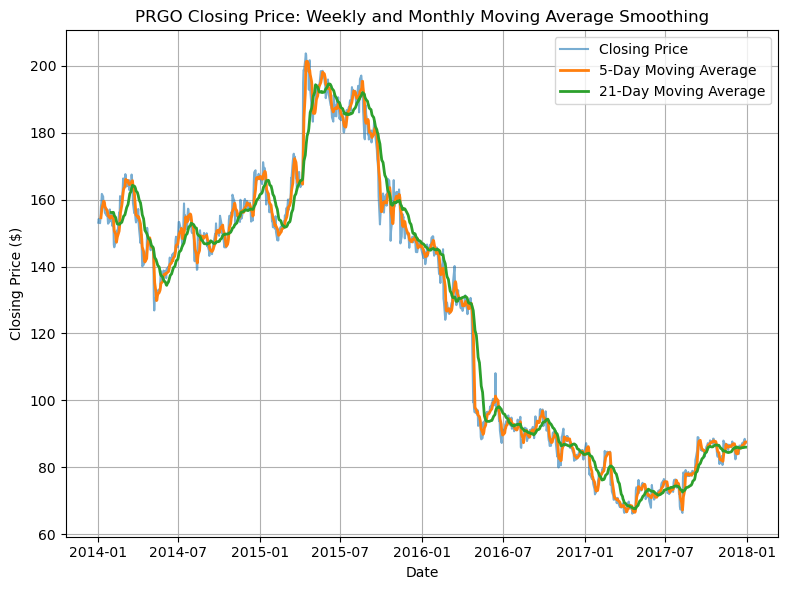

In [30]:
plt.figure(figsize=(8,6))

plt.plot(prgo.index, prgo["close"], label="Closing Price", alpha=0.6)
plt.plot(prgo.index, prgo["MA_5"], label= "5-Day Moving Average", linewidth=2)
plt.plot(prgo.index, prgo["MA_21"], label= "21-Day Moving Average", linewidth=2)

plt.title("PRGO Closing Price: Weekly and Monthly Moving Average Smoothing")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

**MOVING AVERAGE SMOOTHING INTERPRETATION- PRGO**

The moving average analysis reveals a clear distinction between PRGO's short-term fluctuations and its underlying medium-term trend. The **5-day** moving average closely follows the daily closing price, capturing short-term momentum while reducing some day-to-day noise. The **21-day** moving average produces a smoother series and provides a clearer view of the broader price direction. PRGO experienced considerable
price fluctuations during 2014 and 2015, followed by a pronounced downward trend beginning in late 2015. The 21-day moving average clearly captures this sustained decline and the subsequent stabilization and modest recovery during 2017. The increasing lag of the 21-day moving average during sharp price movements demonstrates the trade-off between smoothing and responsiveness.

# CONCLUSION

Both Decomposition and Moving Average tell the same story: NVDA and PRGO trended in different closing price trajectoriess during the period of study.
**NVDA** exhibited a strong and sustained upward trend, with closing price progressively increasing throughout the latter part of the study period. In contrast, **PRGO** shows considerable short-term fluctuations followed by a prolonged downward trend after its 2015 peak. 

**Overall**, the moving average analysis reinforces the findings from seasonal decomposition: **NVDA experienced sustained growth** during the study period, whereas **PRGO experienced a significant long-term decline** followed by a slight stabilization.